<a href="https://colab.research.google.com/github/Ramya-sri123/Machine-Learning/blob/main/Logistic_Regression_Handson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# DATASET LINK :- https://drive.google.com/file/d/1KEkAqdwojbLEjoafTvUt-LCcBqf8imQk/view

In [30]:
import pandas as pd

In [32]:
df=pd.read_csv('/content/bank-additional-full-1.csv',sep=';')

In [33]:
df.shape

(41199, 21)

In [ ]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [35]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,149.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,226.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,151.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,307.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [37]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41195.000000,41196.000000,41196.000000,41196.000000,41196.000000,41196.000000,41195.000000,41196.000000,41196.000000,41196.000000
mean,40.030319,258.281265,2.567676,962.482547,0.173124,0.081656,93.575867,-40.504600,3.620787,5166.996405
std,10.431818,259.254211,2.769751,186.893451,0.494987,1.570894,0.578999,4.629972,1.734655,72.300104
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [38]:
df.isnull().sum()

,0
age,4
job,5
marital,5
education,5
default,4
housing,3
loan,4
contact,4
month,3
day_of_week,3


In [39]:
# fill the null values for both categorical and numerical cols
num_col=df.select_dtypes(include=['int64','float64']).columns
for col in num_col:
  df[col].fillna(df[col].median(),inplace=True)

/tmp/ipykernel_796/2451673847.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


In [40]:
cat_col=df.select_dtypes(include='object').columns
for col in cat_col:
  df[col].fillna(df[col].mode()[0],inplace=True)


/tmp/ipykernel_796/3822209048.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [41]:
# printing the correlation table
# plotting a graph for the same
corr=df.corr(numeric_only=True)
corr


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000905,0.004684,-0.034217,0.025331,-0.000827,0.001937,0.127847,0.009853,-0.019371
duration,-0.000905,1.000000,-0.071696,-0.047584,0.020618,-0.027969,0.005277,-0.008131,-0.032883,-0.044635
campaign,0.004684,-0.071696,1.000000,0.052586,-0.079063,0.150710,0.127840,-0.013790,0.135044,0.143893
pdays,-0.034217,-0.047584,0.052586,1.000000,-0.587291,0.270964,0.078934,-0.091386,0.296781,0.372213
previous,0.025331,0.020618,-0.079063,-0.587291,1.000000,-0.420604,-0.202411,-0.051612,-0.454765,-0.501729
emp.var.rate,-0.000827,-0.027969,0.150710,0.270964,-0.420604,1.000000,0.774743,0.196244,0.972199,0.906632
cons.price.idx,0.001937,0.005277,0.127840,0.078934,-0.202411,0.774743,1.000000,0.058137,0.687300,0.520444
cons.conf.idx,0.127847,-0.008131,-0.013790,-0.091386,-0.051612,0.196244,0.058137,1.000000,0.278118,0.101596
euribor3m,0.009853,-0.032883,0.135044,0.296781,-0.454765,0.972199,0.687300,0.278118,1.000000,0.945035
nr.employed,-0.019371,-0.044635,0.143893,0.372213,-0.501729,0.906632,0.520444,0.101596,0.945035,1.000000


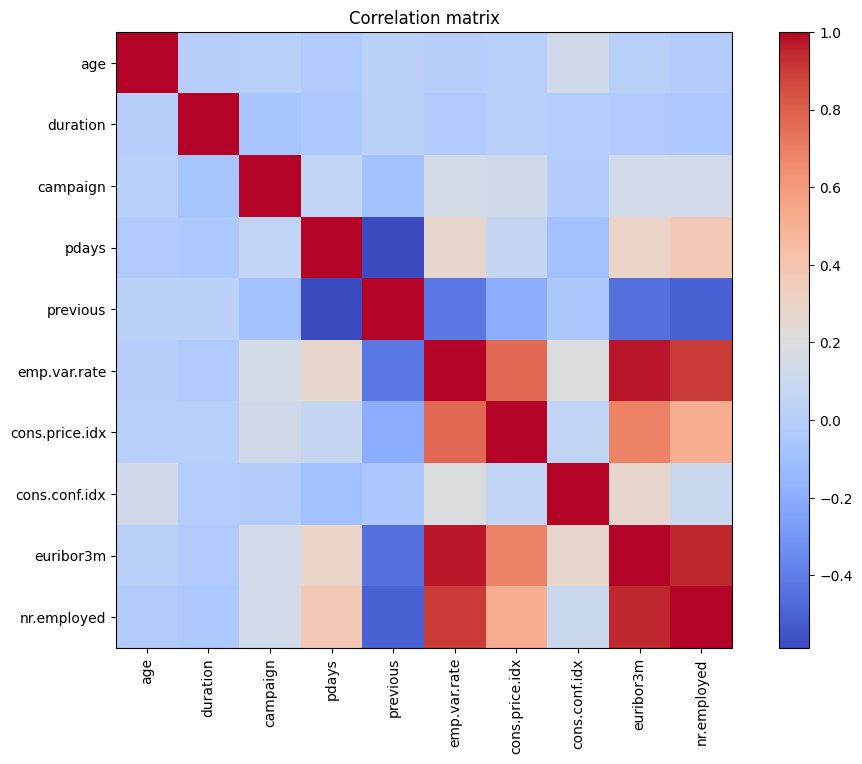

In [42]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.imshow(corr,cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title('Correlation matrix')
plt.show()

In [ ]:
# Plot boxplots for all columns find out in which all columns we have outliers as well as identify fronm which all cols u will be removing the outliers from and why?

In [43]:
df.duplicated().sum()

np.int64(16)

In [44]:
df.drop_duplicates(inplace=True)

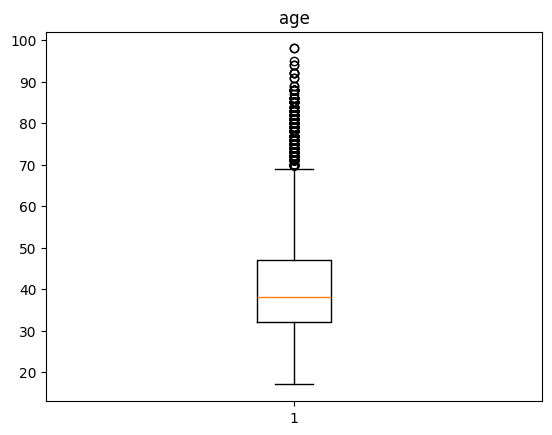

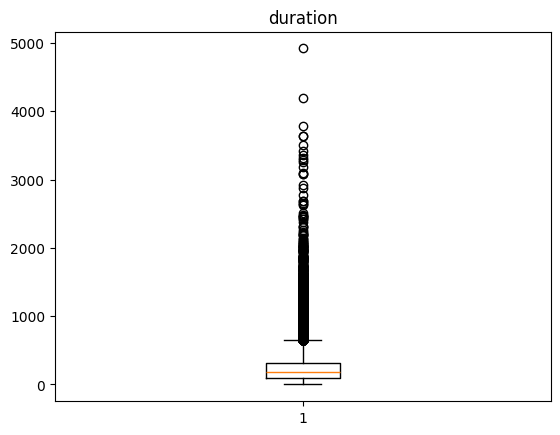

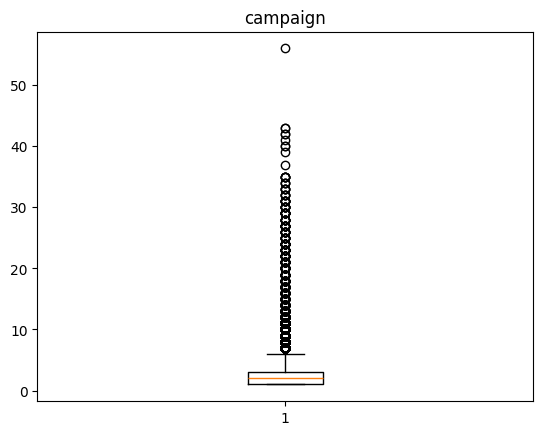

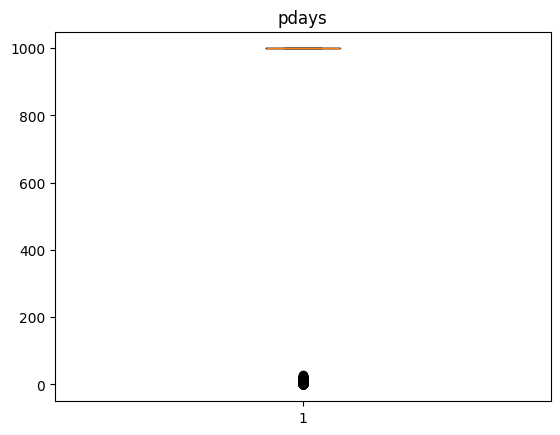

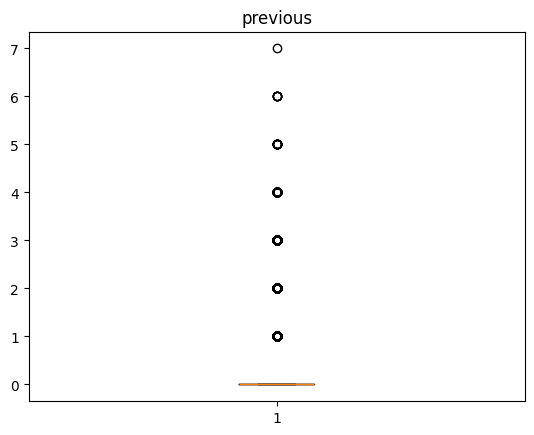

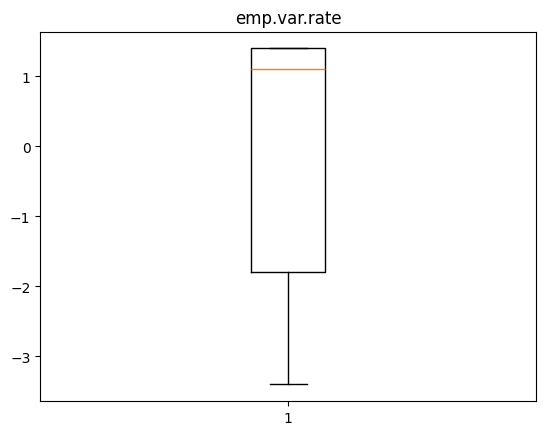

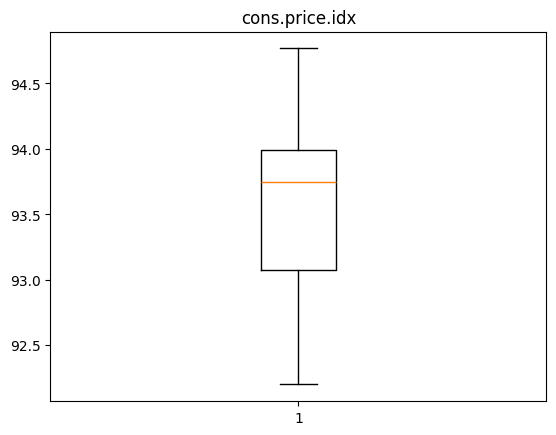

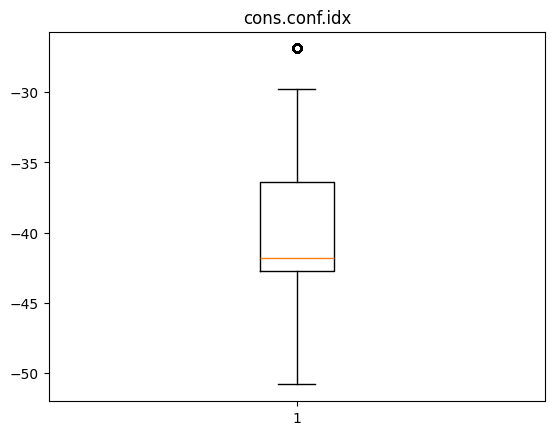

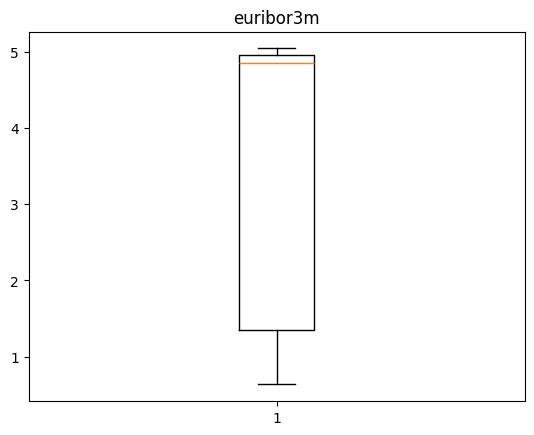

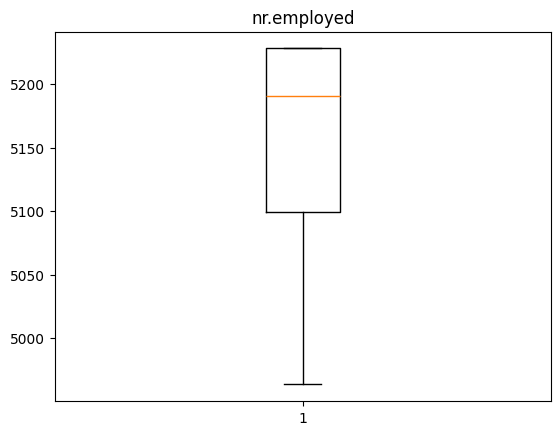

In [45]:
import matplotlib.pyplot as plt

for i in df.columns:
  if(df[i].dtype!='object'):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [ ]:
# Remove outliers from the stated columns as well as you will label encode on the relevant columns

In [46]:
outliers_col=['duration','campaign']
for col in outliers_col:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  df=df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35958 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             35958 non-null  float64
 1   job             35958 non-null  object 
 2   marital         35958 non-null  object 
 3   education       35958 non-null  object 
 4   default         35958 non-null  object 
 5   housing         35958 non-null  object 
 6   loan            35958 non-null  object 
 7   contact         35958 non-null  object 
 8   month           35958 non-null  object 
 9   day_of_week     35958 non-null  object 
 10  duration        35958 non-null  float64
 11  campaign        35958 non-null  float64
 12  pdays           35958 non-null  float64
 13  previous        35958 non-null  float64
 14  poutcome        35958 non-null  object 
 15  emp.var.rate    35958 non-null  float64
 16  cons.price.idx  35958 non-null  float64
 17  cons.conf.idx   35958 non-null  floa

In [48]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
  if(df[col].dtype=='object'):
    df[col]=le.fit_transform(df[col])

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35958 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             35958 non-null  float64
 1   job             35958 non-null  int64  
 2   marital         35958 non-null  int64  
 3   education       35958 non-null  int64  
 4   default         35958 non-null  int64  
 5   housing         35958 non-null  int64  
 6   loan            35958 non-null  int64  
 7   contact         35958 non-null  int64  
 8   month           35958 non-null  int64  
 9   day_of_week     35958 non-null  int64  
 10  duration        35958 non-null  float64
 11  campaign        35958 non-null  float64
 12  pdays           35958 non-null  float64
 13  previous        35958 non-null  float64
 14  poutcome        35958 non-null  int64  
 15  emp.var.rate    35958 non-null  float64
 16  cons.price.idx  35958 non-null  float64
 17  cons.conf.idx   35958 non-null  floa

In [50]:
x=df.drop('y',axis=1)
y=df['y']

In [51]:
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56.0,3,1,0,0,0,0,1,6,1,261.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
1,57.0,7,1,3,1,0,0,1,6,1,149.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
2,37.0,7,1,3,0,2,0,1,6,1,226.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
3,40.0,0,1,1,0,0,0,1,6,1,151.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
4,56.0,7,1,3,0,0,2,1,6,1,307.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41190,74.0,0,1,6,0,2,0,0,7,0,239.0,3.0,999.0,1.0,1,-1.1,94.767,-50.8,1.028,4963.6
41193,94.0,5,1,5,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767,-50.8,1.028,4963.6
41195,74.0,0,1,5,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767,-50.8,1.028,4963.6
41196,74.0,5,1,6,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767,-50.8,1.028,4963.6


In [52]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
41190,0
41193,0
41195,0
41196,0


In [53]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [54]:
x_train

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
22095,54.0,1,1,7,0,2,0,0,1,4,99.0,3.0,999.0,0.0,1,1.4,93.444,-36.1,4.964,5228.1
584,45.0,11,1,7,1,0,0,1,6,3,315.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
36688,37.0,8,2,7,0,0,0,0,4,0,99.0,1.0,999.0,0.0,1,-2.9,92.963,-40.8,1.268,5076.2
34932,28.0,1,2,1,0,2,2,0,6,0,20.0,6.0,999.0,0.0,1,-1.8,92.893,-46.2,1.250,5099.1
10147,55.0,1,0,0,1,0,0,1,4,2,270.0,1.0,999.0,0.0,1,1.4,94.465,-41.8,4.958,5228.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19780,51.0,1,1,0,1,2,0,0,1,0,205.0,1.0,999.0,0.0,1,1.4,93.444,-36.1,4.966,5228.1
7043,29.0,7,2,3,0,0,0,1,6,2,70.0,2.0,999.0,0.0,1,1.1,93.994,-36.4,4.860,5191.0
13010,33.0,1,2,2,0,2,0,0,3,3,154.0,3.0,999.0,0.0,1,1.4,93.918,-42.7,4.962,5228.1
910,42.0,1,0,1,1,2,0,1,6,4,107.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.856,5191.0


In [55]:
y_train

,y
22095,0
584,0
36688,0
34932,0
10147,0
...,...
19780,0
7043,0
13010,0
910,0


In [56]:
x_test

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
27513,34.0,9,1,5,0,2,0,0,7,0,251.0,2.0,999.0,0.0,1,-0.1,93.200,-42.0,4.021,5195.8
6574,49.0,1,1,2,1,2,0,1,6,4,27.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
4412,42.0,9,1,2,0,0,0,1,6,3,610.0,2.0,999.0,0.0,1,1.1,93.994,-36.4,4.856,5191.0
23048,44.0,0,1,6,0,0,0,0,1,3,102.0,1.0,999.0,0.0,1,1.4,93.444,-36.1,4.965,5228.1
3225,40.0,10,0,3,0,0,0,1,6,2,101.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.860,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21632,31.0,0,1,6,0,0,2,0,1,3,438.0,1.0,999.0,0.0,1,1.4,93.444,-36.1,4.963,5228.1
2476,40.0,1,0,2,1,2,2,1,6,3,265.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.856,5191.0
31429,34.0,0,1,3,0,0,0,0,6,4,350.0,2.0,999.0,1.0,0,-1.8,92.893,-46.2,1.334,5099.1
15893,26.0,7,2,3,0,2,0,0,3,1,256.0,1.0,999.0,0.0,1,1.4,93.918,-42.7,4.960,5228.1


In [58]:
y_test

,y
27513,0
6574,0
4412,0
23048,0
3225,0
...,...
21632,0
2476,0
31429,0
15893,0


In [59]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [60]:
predict_model=lr.predict(x_test)


In [61]:
predict_model

array([0, 0, 0, ..., 0, 0, 1])

In [62]:
y_test

,y
27513,0
6574,0
4412,0
23048,0
3225,0
...,...
21632,0
2476,0
31429,0
15893,0


In [64]:
from sklearn.metrics import *
accuracy_score(y_test,predict_model)

0.9271412680756396